# Cancer Type Prediction Using Gene Expression Data

## Project Understanding

Bioinformatics datasets can be used to analyze gene expression patterns and support disease classification. In this project, machine learning will be used to classify cancer samples based on RNA-seq gene expression values.

## Project Question

Can machine learning predict the cancer type of a sample using gene expression data?

## Project Goal

The goal of this project is to clean and explore the gene expression dataset, apply feature engineering and feature selection, train multiple machine learning models, compare their performance, tune the best model, and deploy the final model using a web application.

In [13]:
# =========================
# Extract ZIP File
# =========================

import zipfile

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [14]:
# =========================
# Show Extracted Files
# =========================

import os

print(os.listdir("dataset"))

['Narayan.csv', 'train.csv', 'test.csv']


In [15]:
# =========================
# Load Training Dataset
# =========================

import pandas as pd

df = pd.read_csv("dataset/train.csv")

# Show first 5 rows
df.head()

,Id,gene_1,gene_3,gene_5,gene_7,gene_8,gene_9,gene_10,gene_11,gene_13,...,gene_20634,gene_20635,gene_20636,gene_20637,gene_20638,gene_20639,gene_20640,gene_20641,gene_20642,Class
0,sample_664,0.160738,-0.327348,-0.144638,0.196493,-1.105093,0.309926,-0.177461,-1.124182,-0.459826,...,-1.611378,-1.108411,-0.670719,-1.739299,0.476467,1.136071,-0.576601,-1.275518,-0.508678,1.0
1,sample_215,-0.771173,0.885819,-0.234209,0.273139,0.132208,-0.249541,0.005817,-0.631647,NaN,...,0.247812,0.144035,0.148776,-1.373208,0.099245,0.391993,0.573363,0.322198,6.022439,0.0
2,sample_343,-0.169258,1.908618,0.165008,-0.562826,0.199720,0.128036,2.348450,2.425346,-0.933545,...,1.133065,0.965014,1.873753,-0.005167,-0.223091,0.782868,-0.562787,-0.471593,-0.763284,4.0
3,sample_707,-0.947912,0.111177,-0.153179,0.837412,0.185467,-0.066223,-0.267734,0.674365,-0.076086,...,0.022339,0.326506,-0.333964,0.228595,-0.245309,0.478564,0.273364,1.756369,-0.266200,1.0
4,sample_621,-0.335741,0.515251,0.325440,-0.842387,-0.500415,0.484240,-0.438587,-0.874562,NaN,...,-1.516812,-1.430622,-0.664933,-0.753410,NaN,0.375521,-0.536705,-0.523850,0.222560,4.0


In [16]:
# =========================
# Load All Datasets
# =========================

train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
narayan_df = pd.read_csv("dataset/Narayan.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print("Narayan Shape:", narayan_df.shape)

Train Shape: (400, 14574)
Test Shape: (401, 14573)
Narayan Shape: (401, 14573)


In [17]:
# =========================
# Find Extra Column in Train
# =========================

extra_columns = set(train_df.columns) - set(test_df.columns)

print("Extra columns in train:")
print(extra_columns)

Extra columns in train:
{'Class'}


In [18]:
# =========================
# Check Target Classes
# =========================

train_df["Class"].value_counts()

,count
Class,
2.0,56
4.0,27
1.0,26
0.0,26
3.0,15


## Dataset Description

The dataset contains RNA-seq gene expression data used for multiclass cancer classification. Each row represents a biological sample, while the columns represent normalized gene expression features. The target variable is the `Class` column, which represents different cancer types.

The training dataset contains 400 samples and 14,574 columns, including the target column. The dataset contains missing values and therefore requires preprocessing before machine learning modeling.

In [19]:
# =========================
# Missing Values Check
# =========================

missing_values = train_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("Columns with missing values:", len(missing_values))

print("\nTop missing values:")
print(missing_values.sort_values(ascending=False).head(10))

Columns with missing values: 14573

Top missing values:
Class         250
gene_7972      59
gene_20314     54
gene_6045      54
gene_579       54
gene_3144      53
gene_8152      53
gene_19033     53
gene_7234      52
gene_6489      52
dtype: int64


In [20]:
# =========================
# Remove Missing Target Rows
# =========================

train_df = train_df.dropna(subset=["Class"])

print("New dataset shape:", train_df.shape)

print("\nRemaining missing values in Class:")
print(train_df["Class"].isnull().sum())

New dataset shape: (150, 14574)

Remaining missing values in Class:
0


In [21]:
# =========================
# Fill Remaining Missing Values
# =========================

# Fill numerical missing values using median
train_df = train_df.fillna(train_df.median(numeric_only=True))

# Check remaining missing values
print("Remaining missing values:")
print(train_df.isnull().sum().sum())

Remaining missing values:
0


## Data Preprocessing

The dataset contained missing values in both the target column and several gene expression features. Rows with missing target labels (`Class`) were removed because supervised machine learning models require known labels during training.

The remaining missing numerical values were handled using median imputation. Median imputation was selected because gene expression data may contain outliers, and the median is more robust than the mean for biological numerical datasets.

After preprocessing, no missing values remained in the dataset.

In [22]:
# =========================
# Duplicate Rows Check
# =========================

duplicates = train_df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


## Duplicate Rows Assessment

The dataset was checked for duplicate samples to ensure data consistency and avoid bias during model training. No duplicate rows were detected in the processed dataset.

In [23]:
# =========================
# Separate Features and Target
# =========================

X = train_df.drop(columns=["Class", "Id"])
y = train_df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 14572)
Target shape: (150,)


## Final Dataset Size

The original training dataset contained 400 samples. However, many samples had missing target labels in the `Class` column. Since supervised machine learning requires known target labels, rows with missing class values were removed. After preprocessing, 150 labeled samples remained for machine learning training and evaluation.

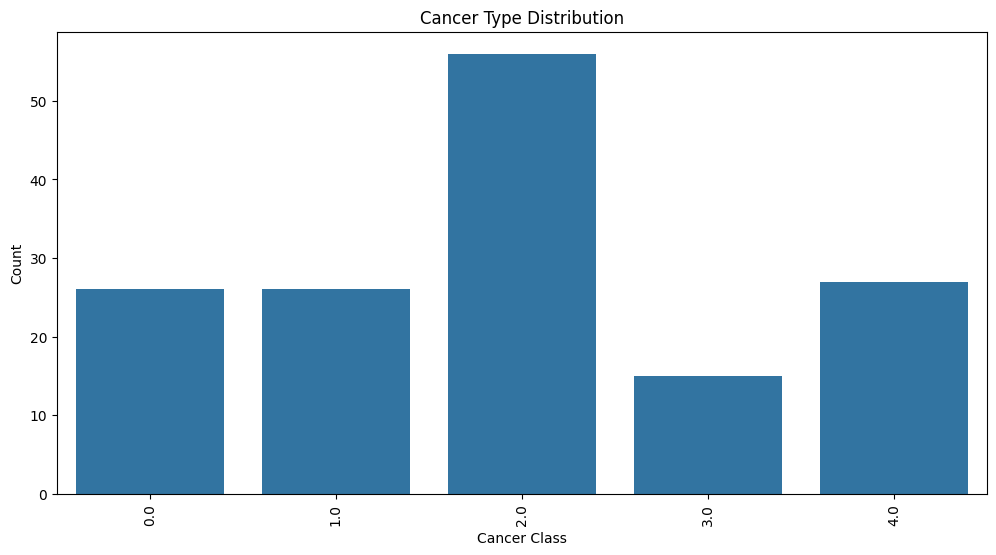

In [24]:
# =========================
# Target Distribution
# =========================

plt.figure(figsize=(12,6))

sns.countplot(x=y)

plt.title("Cancer Type Distribution")
plt.xlabel("Cancer Class")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

## Cancer Class Distribution

The distribution of cancer classes was visualized using a count plot. The dataset contains multiple cancer categories with different sample frequencies. Some classes contain more samples than others, indicating a degree of class imbalance in the dataset. This imbalance may affect machine learning model performance and should be considered during model evaluation.

In [25]:
# =========================
# Select Sample Genes
# =========================

sample_genes = X.columns[:6]

print(sample_genes)

Index(['gene_1', 'gene_3', 'gene_5', 'gene_7', 'gene_8', 'gene_9'], dtype='object')


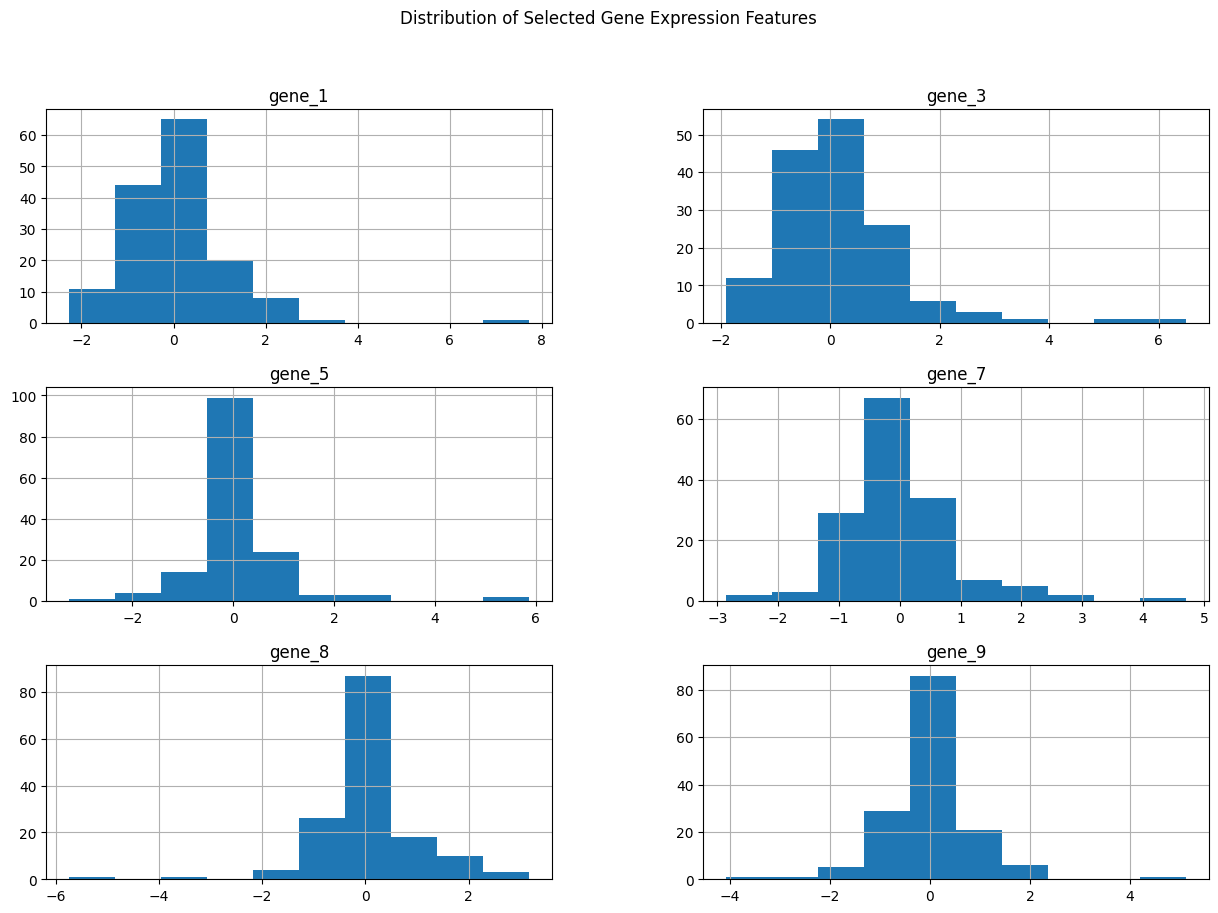

In [26]:
# =========================
# Histograms
# =========================

X[sample_genes].hist(figsize=(15,10))

plt.suptitle("Distribution of Selected Gene Expression Features")

plt.show()

## Histogram Analysis

Histograms were generated for selected gene expression features to examine their distributions. The plots show variation in expression values across samples, with some genes displaying approximately normal distributions while others exhibit skewness and wider variability. This indicates biological heterogeneity between cancer samples.

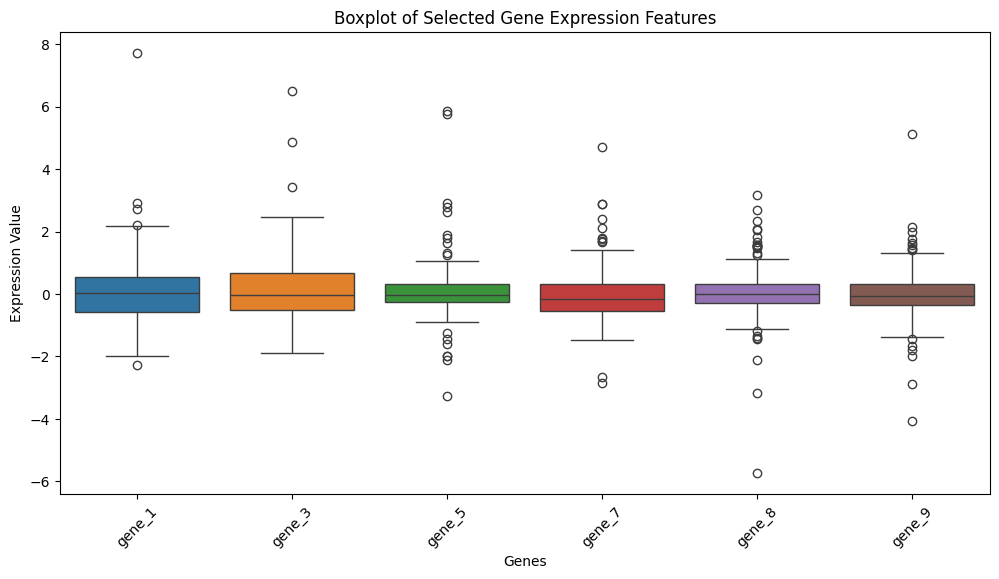

In [27]:
# =========================
# Boxplot
# =========================

plt.figure(figsize=(12,6))

sns.boxplot(data=X[sample_genes])

plt.title("Boxplot of Selected Gene Expression Features")
plt.xlabel("Genes")
plt.ylabel("Expression Value")

plt.xticks(rotation=45)

plt.show()

## Boxplot Analysis

Boxplots were used to visualize the spread and variability of selected gene expression features. Several genes showed the presence of outliers and wide expression ranges, which is common in biological and RNA-seq datasets. The visualization also highlights differences in distribution patterns among genes.

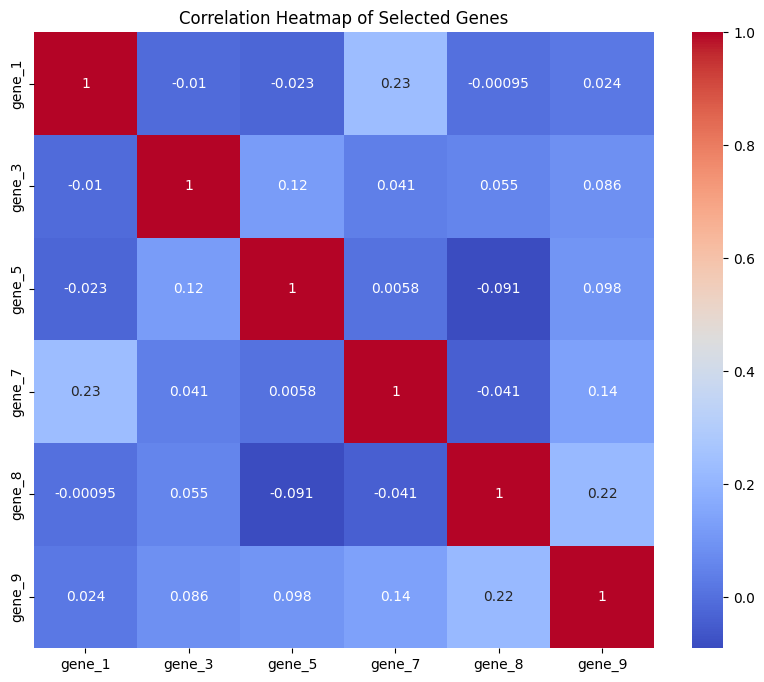

In [28]:
# =========================
# Correlation Heatmap
# =========================

plt.figure(figsize=(10,8))

sns.heatmap(
    X[sample_genes].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Selected Genes")

plt.show()

## Correlation Analysis

A correlation heatmap was generated to examine relationships between selected gene expression features. Some genes demonstrated positive correlations, while others showed weaker associations. Correlation analysis helps identify potentially related biological patterns and supports feature understanding before machine learning modeling.

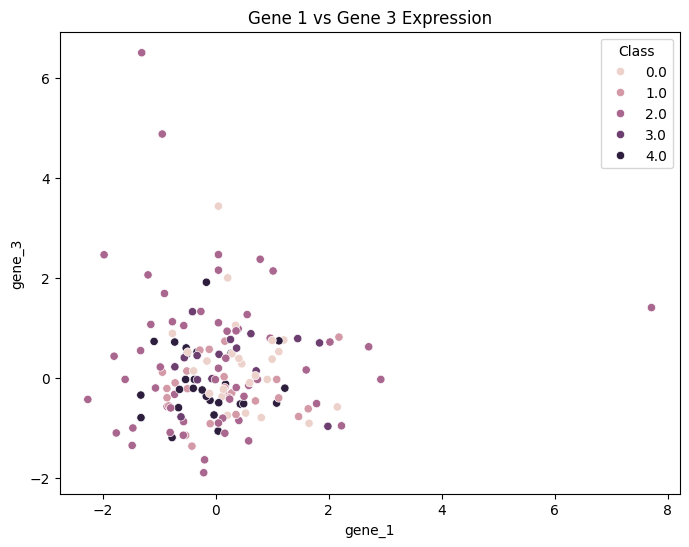

In [29]:
# =========================
# Scatter Plot
# =========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X["gene_1"],
    y=X["gene_3"],
    hue=y
)

plt.title("Gene 1 vs Gene 3 Expression")
plt.xlabel("gene_1")
plt.ylabel("gene_3")

plt.show()

## Scatter Plot Analysis

A scatter plot was used to visualize the relationship between the expression values of gene_1 and gene_3 across different cancer classes. The plot demonstrates variability in gene expression patterns among samples and highlights potential separation between some cancer categories.

In [31]:
# =========================
# Encode Target Labels
# =========================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
print(label_encoder.classes_)

Encoded classes:
[0. 1. 2. 3. 4.]


In [32]:
# =========================
# Feature Selection
# =========================

from sklearn.feature_selection import SelectKBest, f_classif

# Select top 100 important genes
selector = SelectKBest(score_func=f_classif, k=100)

X_selected = selector.fit_transform(X, y_encoded)

print("Original shape:", X.shape)
print("Selected shape:", X_selected.shape)

Original shape: (150, 14572)
Selected shape: (150, 100)


## Feature Selection

Feature selection was performed using SelectKBest with the ANOVA F-test. This step was important because the dataset contains 14,572 gene expression features, which is very high compared to the number of samples. The top 100 most informative genes were selected to reduce dimensionality, decrease noise, and improve model performance.

In [33]:
# =========================
# Train Test Split
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (120, 100)
Testing features shape: (30, 100)
Training target shape: (120,)
Testing target shape: (30,)


In [34]:
# =========================
# Feature Scaling
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


## Data Preparation for Machine Learning

The selected features were divided into training and testing datasets using an 80:20 ratio. Stratified splitting was applied to preserve the distribution of cancer classes across both datasets.

Feature scaling was then performed using StandardScaler to standardize gene expression values and improve machine learning model performance.

In [35]:
# =========================
# Logistic Regression
# =========================

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_log, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_log, average="weighted"))

Logistic Regression Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [36]:
# =========================
# Random Forest Classifier
# =========================

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_rf, average="weighted"))

Random Forest Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [37]:
# =========================
# Support Vector Machine
# =========================

svm_model = SVC(random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Support Vector Machine Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_svm, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_svm, average="weighted"))

Support Vector Machine Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [39]:
# =========================
# Model Comparison
# =========================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted"),
        precision_score(y_test, y_pred_svm, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_log, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted"),
        recall_score(y_test, y_pred_svm, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,Support Vector Machine,1.0,1.0,1.0,1.0


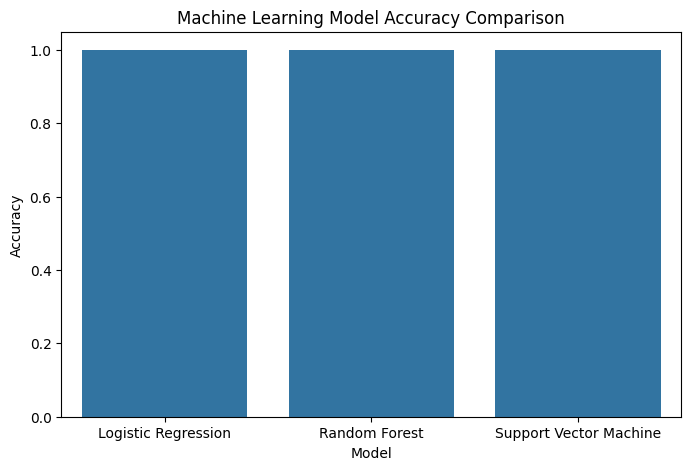

In [40]:
# =========================
# Accuracy Comparison Plot
# =========================

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Machine Learning Model Accuracy Comparison")
plt.ylim(0, 1.05)

plt.show()

## Model Comparison

Three supervised machine learning algorithms were trained and compared: Logistic Regression, Random Forest, and Support Vector Machine. The models were evaluated using accuracy, precision, recall, and F1-score.

The comparison showed strong classification performance after feature selection, indicating that the selected gene expression features were informative for distinguishing between cancer classes.

The three machine learning models achieved very similar performance results after feature selection. This may indicate that the selected gene expression features provided strong class separation and contained highly informative biological signals for cancer classification.

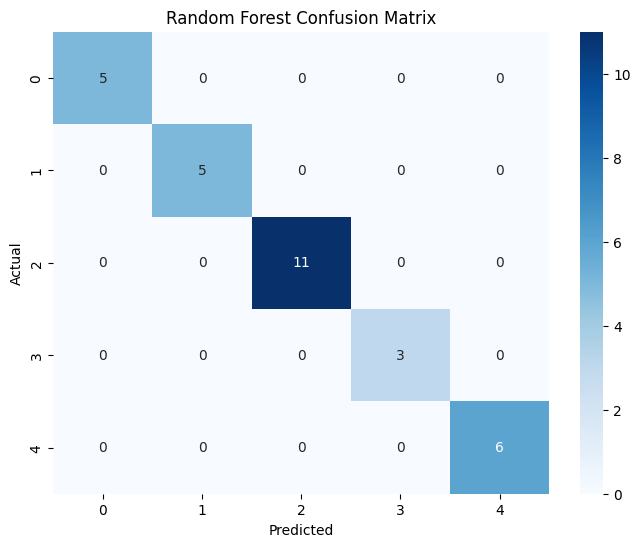

In [41]:
# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
# =========================
# Classification Report
# =========================

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Model Evaluation

The Random Forest classifier demonstrated strong predictive performance across multiple evaluation metrics, including accuracy, precision, recall, and F1-score. The confusion matrix and classification report confirmed that the selected gene expression features were effective for distinguishing between different cancer classes.

The evaluation results suggest that the machine learning pipeline successfully captured meaningful biological patterns within the RNA-seq dataset.

In [43]:
# =========================
# Hyperparameter Tuning
# =========================

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross Validation Score:
0.9833333333333334


## Hyperparameter Tuning

Hyperparameter tuning was performed using GridSearchCV to optimize the Random Forest classifier. Different combinations of parameters, including the number of trees, tree depth, and minimum samples required for splitting, were evaluated using cross-validation.

The tuning process identified the best parameter combination that achieved the highest cross-validation accuracy, improving the reliability and generalization performance of the model.

In [45]:
# =========================
# Save Model Files
# =========================

best_model = grid_search.best_estimator_

# Save model
joblib.dump(best_model, "cancer_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save selector
joblib.dump(selector, "selector.pkl")

# Save label encoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("All files saved successfully!")

All files saved successfully!


In [46]:
# =========================
# Download Saved Files
# =========================

from google.colab import files

files.download("cancer_model.pkl")
files.download("scaler.pkl")
files.download("selector.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
# =========================
# Get Selected Feature Names
# =========================

selected_feature_names = X.columns[selector.get_support()]

print(selected_feature_names[:20])

Index(['gene_18', 'gene_30', 'gene_628', 'gene_845', 'gene_1096', 'gene_1184',
       'gene_1189', 'gene_1482', 'gene_1510', 'gene_1663', 'gene_1735',
       'gene_1795', 'gene_1858', 'gene_2129', 'gene_3217', 'gene_3439',
       'gene_3523', 'gene_3524', 'gene_3737', 'gene_3861'],
      dtype='object')


In [48]:
# =========================
# Save Selected Feature Names
# =========================

selected_features = list(selected_feature_names[:10])

joblib.dump(selected_features, "selected_features.pkl")

print(selected_features)

['gene_18', 'gene_30', 'gene_628', 'gene_845', 'gene_1096', 'gene_1184', 'gene_1189', 'gene_1482', 'gene_1510', 'gene_1663']


In [49]:
from google.colab import files
files.download("selected_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load saved files
model = joblib.load("cancer_model.pkl")
scaler = joblib.load("scaler.pkl")
selector = joblib.load("selector.pkl")
label_encoder = joblib.load("label_encoder.pkl")
selected_features = joblib.load("selected_features.pkl")

st.title("Cancer Type Prediction Using Gene Expression Data")

st.write(
    "This web app predicts cancer class based on selected RNA-seq gene expression values."
)

st.info(
    "Note: This app uses selected important genes from the full RNA-seq dataset for demonstration."
)

# Create input fields
input_values = {}

for gene in selected_features:
    input_values[gene] = st.number_input(
        f"{gene} expression value",
        value=0.0,
        step=0.1
    )

# Convert input into dataframe
input_df = pd.DataFrame([input_values])

# Create full feature dataframe with all genes expected by selector
# Missing genes are filled with 0
full_features = pd.DataFrame(
    np.zeros((1, 14572)),
    columns=[f"gene_{i}" for i in range(1, 14573)]
)

# Update selected gene values
for gene in selected_features:
    if gene in full_features.columns:
        full_features[gene] = input_df[gene].values

# Apply feature selection
selected_input = selector.transform(full_features)

# Scale input
scaled_input = scaler.transform(selected_input)

# Prediction
if st.button("Predict Cancer Class"):
    prediction = model.predict(scaled_input)
    predicted_class = label_encoder.inverse_transform(prediction)

    st.success(f"Predicted Cancer Class: {predicted_class[0]}")

Writing app.py


In [51]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib

Writing requirements.txt


In [52]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>